# Module 1: Signals -- What Electrical Signals from the Body Look Like

This tutorial walks through the concepts step by step. Each section includes an explanation, an example, and an exercise.

## Step 1: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Make plots look nice
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Ready!')

Ready!


First, let's import the libraries we'll use throughout this notebook.

- **NumPy** for numerical computation
- **Matplotlib** for plotting


**Exercise 1:** Try it yourself!

## Step 2: Clinical Vignette

**Clinical scenario:** A 28-year-old woman comes to your clinic with episodes of "staring off" lasting 10-15 seconds, happening several times a day. Her partner says she doesn't respond during these episodes. You order an EEG. The technician hands you a tracing.

Can you tell what's happening? By the end of this notebook, you'll understand the building blocks of any electrical signal from the body -- amplitude, frequency, and phase -- and be able to read signals like this.

Every cell in your body produces tiny electrical signals. Neurons fire. Heart muscle contracts. Skeletal muscle twitches. A **signal** is just a measurement that changes over time. When we record an EEG, ECG, or EMG, we're measuring **voltage** (in microvolts or millivolts) at each moment.

The simplest signal is a smooth, repeating wave with two key properties:
- **Amplitude**: How tall the wave is. Bigger amplitude = stronger signal.
- **Frequency**: How fast the wave repeats. Higher frequency = more cycles per second (Hz).

**Exercise 2:** Try it yourself!

## Step 3: Generating a Sine Wave

A sine wave is the fundamental building block of all signals. Every physiological recording -- EEG, ECG, EMG -- can be decomposed into a sum of sine waves.

The formula: $y(t) = A \sin(2\pi f t)$

where $A$ is the amplitude and $f$ is the frequency in Hz.

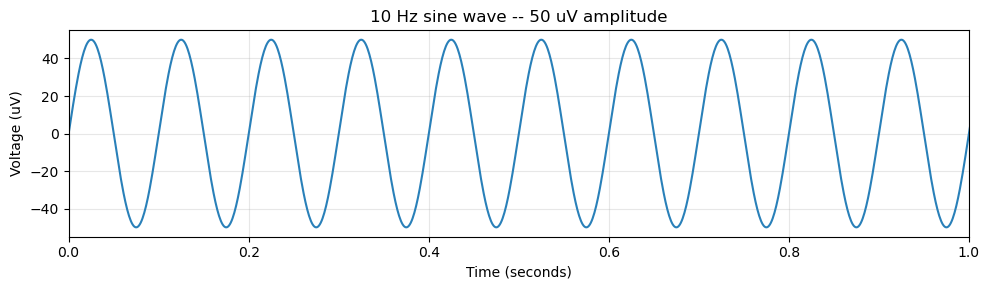

In [2]:
# Parameters
fs = 1000          # Sampling rate (Hz) -- 1000 samples per second
duration = 2.0     # Duration in seconds
t = np.arange(0, duration, 1/fs)  # Time vector

# Generate a 10 Hz sine wave with amplitude 50 microvolts
frequency = 10     # Hz
amplitude = 50     # microvolts
signal = amplitude * np.sin(2 * np.pi * frequency * t)

# Plot it
plt.figure(figsize=(10, 3))
plt.plot(t, signal, color='#2980b9', linewidth=1.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Voltage (uV)')
plt.title(f'{frequency} Hz sine wave -- {amplitude} uV amplitude')
plt.xlim(0, 1)  # Show first second
plt.tight_layout()
plt.show()

**Exercise 3:** Try it yourself!

## Step 4: Clinical Presets: EEG Brain Rhythms

Different brain states produce characteristic frequencies:

| Brain State | Frequency Band | Range | Typical Amplitude |
|---|---|---|---|
| Deep sleep | Delta | 1-4 Hz | 100-200 uV |
| Relaxed, eyes closed | Alpha | 8-13 Hz | 30-50 uV |
| Focused attention | Beta | 13-30 Hz | 10-20 uV |
| Active thinking | Gamma | >30 Hz | 5-10 uV |

**Key pattern:** Slower rhythms tend to be bigger; faster rhythms tend to be smaller. Slow rhythms reflect more neurons firing together (synchrony), which sums to a larger voltage at the scalp.

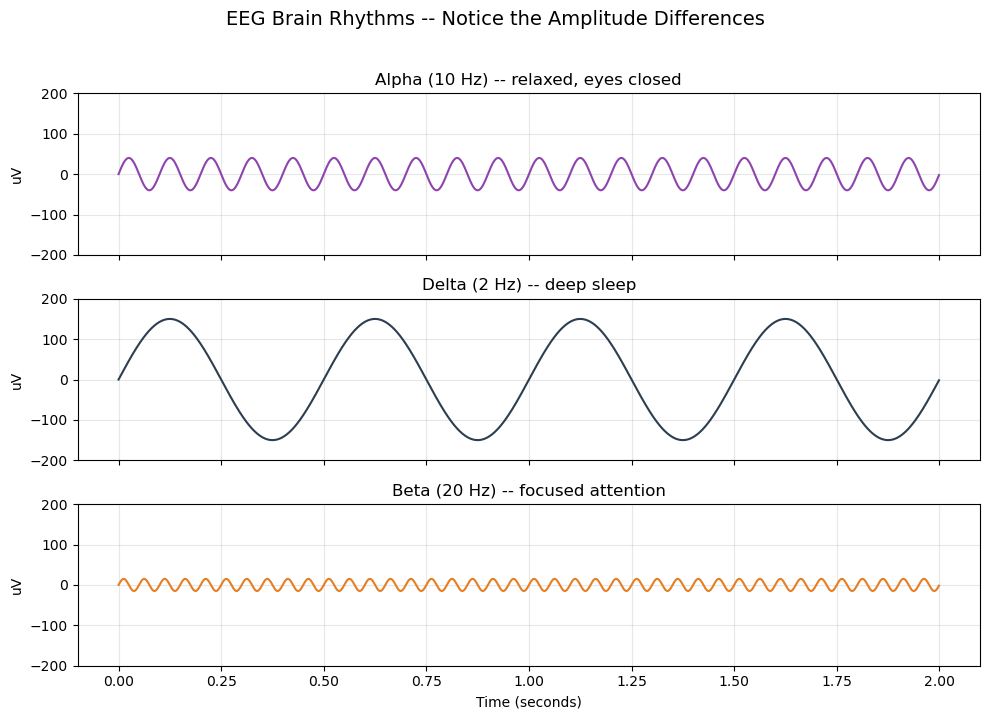

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

presets = [
    {'name': 'Alpha (10 Hz) -- relaxed, eyes closed', 'freq': 10, 'amp': 40, 'color': '#8e44ad'},
    {'name': 'Delta (2 Hz) -- deep sleep', 'freq': 2, 'amp': 150, 'color': '#2c3e50'},
    {'name': 'Beta (20 Hz) -- focused attention', 'freq': 20, 'amp': 15, 'color': '#e67e22'},
]

t = np.arange(0, 2.0, 1/1000)

for ax, p in zip(axes, presets):
    y = p['amp'] * np.sin(2 * np.pi * p['freq'] * t)
    ax.plot(t, y, color=p['color'], linewidth=1.5)
    ax.set_ylabel('uV')
    ax.set_title(p['name'], fontsize=12)
    ax.set_ylim(-200, 200)  # Same scale to show amplitude differences

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('EEG Brain Rhythms -- Notice the Amplitude Differences', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Exercise 4:** Try it yourself!

## Step 5: Generating a Realistic ECG Waveform

An ECG trace is more complex than a simple sine wave. Each heartbeat produces a characteristic pattern called the **P-QRS-T complex**:

- **P wave**: Atrial depolarization (the atria contract)
- **QRS complex**: Ventricular depolarization (the ventricles contract) -- this is the tall spike
- **T wave**: Ventricular repolarization (the ventricles reset)

Notice that the ECG is measured in **millivolts** -- about 1000x larger than EEG.

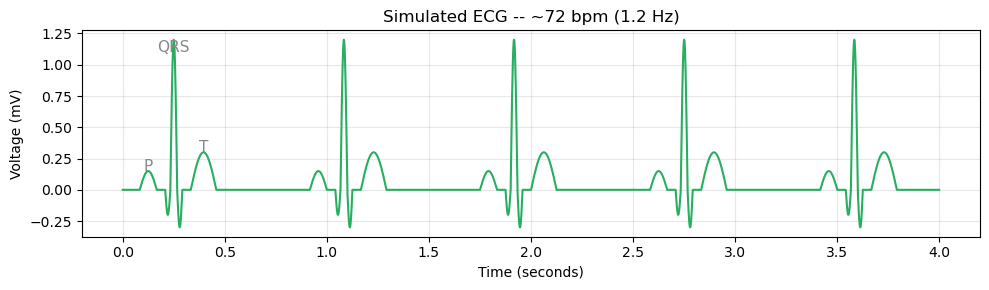

In [4]:
def generate_ecg(duration=4.0, heart_rate_hz=1.2, fs=1000):
    """Generate a simplified but recognizable ECG waveform."""
    t = np.arange(0, duration, 1/fs)
    y = np.zeros_like(t)
    
    for i, ti in enumerate(t):
        phase = (ti * heart_rate_hz) % 1  # Where in the cardiac cycle
        v = 0
        # P wave
        if 0.10 < phase < 0.20:
            v += 0.15 * np.sin(np.pi * (phase - 0.10) / 0.10)
        # QRS complex
        if 0.25 < phase < 0.28:
            v -= 0.20 * np.sin(np.pi * (phase - 0.25) / 0.03)
        if 0.28 < phase < 0.32:
            v += 1.20 * np.sin(np.pi * (phase - 0.28) / 0.04)
        if 0.32 < phase < 0.35:
            v -= 0.30 * np.sin(np.pi * (phase - 0.32) / 0.03)
        # T wave
        if 0.40 < phase < 0.55:
            v += 0.30 * np.sin(np.pi * (phase - 0.40) / 0.15)
        y[i] = v
    
    return t, y

t_ecg, y_ecg = generate_ecg()

plt.figure(figsize=(10, 3))
plt.plot(t_ecg, y_ecg, color='#27ae60', linewidth=1.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Voltage (mV)')
plt.title('Simulated ECG -- ~72 bpm (1.2 Hz)')

# Label the first P-QRS-T
plt.annotate('P', xy=(0.125, 0.15), fontsize=11, color='#888', ha='center')
plt.annotate('QRS', xy=(0.25, 1.1), fontsize=11, color='#888', ha='center')
plt.annotate('T', xy=(0.395, 0.30), fontsize=11, color='#888', ha='center')
plt.tight_layout()
plt.show()

**Exercise 5:** Try it yourself!

## Step 6: Side-by-Side Comparison: EEG vs ECG vs EMG

The same two properties -- amplitude and frequency -- describe signals from different parts of the body, but at very different scales:

| Signal | Typical Amplitude | Typical Frequency | Source |
|---|---|---|---|
| **EEG** (brain) | 10-100 uV | 1-100 Hz | Cortical pyramidal neurons |
| **ECG** (heart) | 0.5-3 mV | ~1 Hz (60 bpm) | Cardiac muscle depolarization |
| **EMG** (muscle) | 0.1-5 mV | 20-500 Hz | Motor unit action potentials |

The ECG is about **1,000x larger** than the EEG. The EMG has **much higher frequencies** than either.

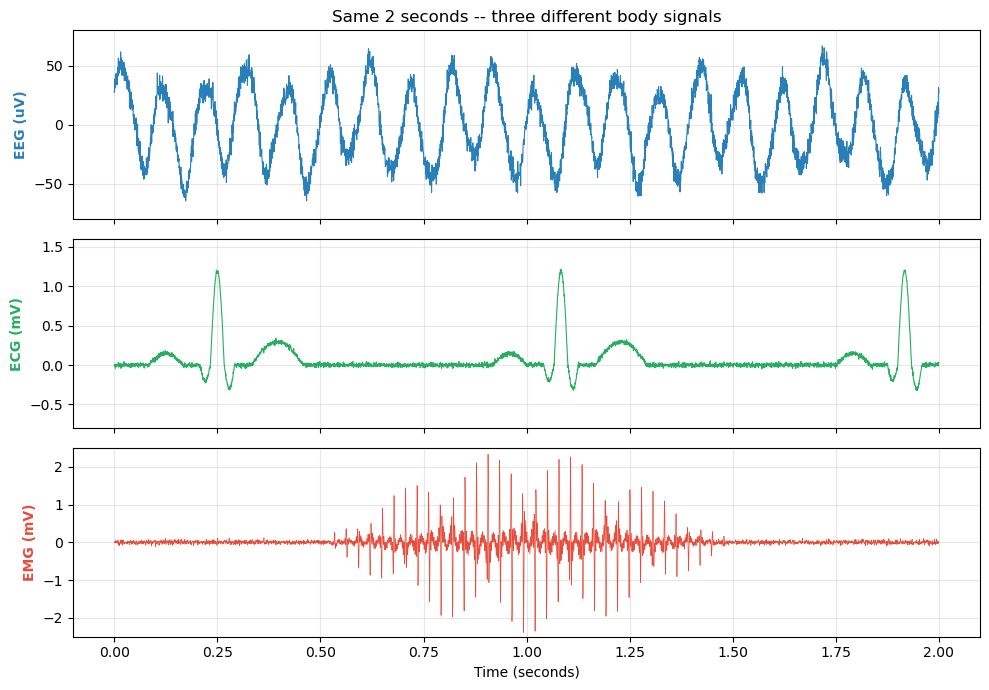

In [5]:
np.random.seed(42)
fs = 2000
t = np.arange(0, 2.0, 1/fs)

# EEG: alpha-dominant with some theta and beta
eeg = (40 * np.sin(2*np.pi*10*t + 0.3)
     + 12 * np.sin(2*np.pi*3.5*t + 1.1)
     + 6 * np.sin(2*np.pi*21*t + 0.7)
     + 10 * np.random.randn(len(t)) * 0.5)

# ECG: P-QRS-T waveform
_, ecg = generate_ecg(duration=2.0, fs=fs)
ecg += 0.015 * np.random.randn(len(ecg))

# EMG: bursts during contraction
emg_envelope = np.where((t > 0.5) & (t < 1.5),
                        1.5 * np.sin(np.pi * (t - 0.5) / 1.0), 0.03)
emg_fast = sum(np.sin(2*np.pi*(40 + k*35)*t + k*1.7) for k in range(1, 9))
emg = emg_envelope * emg_fast / 5 + 0.03 * np.random.randn(len(t))

# Plot side by side
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t, eeg, color='#2980b9', linewidth=0.8)
axes[0].set_ylabel('EEG (uV)', color='#2980b9', fontweight='bold')
axes[0].set_ylim(-80, 80)
axes[0].set_title('Same 2 seconds -- three different body signals')

axes[1].plot(t, ecg, color='#27ae60', linewidth=0.8)
axes[1].set_ylabel('ECG (mV)', color='#27ae60', fontweight='bold')
axes[1].set_ylim(-0.8, 1.6)

axes[2].plot(t, emg, color='#e74c3c', linewidth=0.5)
axes[2].set_ylabel('EMG (mV)', color='#e74c3c', fontweight='bold')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()

**Exercise 6:** Try it yourself!

## Step 7: Phase: Where in the Cycle

Besides amplitude and frequency, signals have a third property: **phase**.

Phase tells you *where in the cycle* the wave is at a given moment. Two signals can have the same frequency and amplitude but be offset from each other -- like two runners on the same track, one slightly ahead.

**Clinical relevance:** Neurologists use **phase reversal** to pinpoint where a seizure starts. When one electrode's signal flips relative to its neighbor, it marks the epileptic focus.

In [ ]:
t = np.arange(0, 1.5, 1/500)
freq, amp = 5, 5  # 5 Hz, 5 uV

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

phase_offsets = [0, 90, 180, 360]
titles = ['0 deg (in phase)', '90 deg (quarter cycle)',
          '180 deg (opposite!)', '360 deg = 0 deg (back to identical)']

for ax, deg, title in zip(axes.flat, phase_offsets, titles):
    rad = np.deg2rad(deg)
    y1 = amp * np.sin(2 * np.pi * freq * t)
    y2 = amp * np.sin(2 * np.pi * freq * t + rad)
    ax.plot(t, y1, color='#2980b9', linewidth=2, label='Electrode A')
    ax.plot(t, y2, color='#8e44ad', linewidth=2, linestyle='--', label='Electrode B')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-7, 7)
    ax.set_xlabel('Time (s)')
    ax.legend(fontsize=8)

plt.suptitle('Phase: Same Frequency, Different Alignment', fontsize=13)
plt.tight_layout()
plt.show()

**Exercise 7:** Try it yourself!

## Step 8: Exercise: Combine Alpha and Beta

Now it's your turn. Real EEG signals are mixtures of multiple frequencies. Create a signal that combines alpha (10 Hz) and beta (20 Hz) rhythms, then plot it.

**Hint:** Just add two sine waves together: `signal = wave1 + wave2`

**Exercise 8:** Try it yourself!

In [ ]:
# YOUR CODE HERE
# Task: Create a signal that combines alpha (10 Hz, amplitude 30 uV)
# and beta (20 Hz, amplitude 10 uV) rhythms. Plot it.
#
# Steps:
# 1. Create a time vector: t = np.arange(0, 2.0, 1/1000)
# 2. Generate alpha: alpha = 30 * np.sin(2 * np.pi * 10 * t)
# 3. Generate beta: beta = 10 * np.sin(2 * np.pi * 20 * t)
# 4. Combine: combined = alpha + beta
# 5. Plot with plt.plot(t, combined)


## Step 9: Exercise: Phase Cancellation

What happens when you add two signals with the same frequency and amplitude but 180 degrees phase difference? This is called **destructive interference** and it's fundamental to how noise cancellation works.

**Exercise 9:** Try it yourself!

In [ ]:
# YOUR CODE HERE
# Task: Add two 10 Hz signals with the same amplitude but 180 deg phase offset.
# What do you get? Plot both individual signals AND the sum.
#
# Hint:
# t = np.arange(0, 1.0, 1/1000)
# signal_1 = 5 * np.sin(2 * np.pi * 10 * t)
# signal_2 = 5 * np.sin(2 * np.pi * 10 * t + np.pi)  # 180 deg = pi radians
# combined = signal_1 + signal_2
#
# Try plotting all three on the same axes.
# What is the amplitude of the combined signal?
